# Phase 8 (Notebook 08): Comparative Analysis & Final Synthesis

## Objective
This notebook provides the **complete cross-phase synthesis** of all experiments run across the project.
Rather than introducing new training, we collect results from all previous phases and answer
the overarching research questions:

- Which RL family (tabular / deep / policy gradient) is best suited for Mountain Car?
- How do discretization granularity, reward design, and hyperparameters interact?
- What are the performance vs. interpretability trade-offs?
- What practical guidelines can we extract for future RL projects?

## Structure
1. **Re-run all methods** – Tabular (Q-Learning, SARSA), DQN/DDQN, REINFORCE, Actor-Critic under a unified config
2. **Master comparison table** – all methods × all scenarios
3. **Learning curve overlay** – convergence comparison across families
4. **Policy comparison** – heatmaps side by side
5. **Efficiency analysis** – sample efficiency, training time, seed robustness
6. **Key findings & practical guidelines**

In [1]:
import sys, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

warnings.filterwarnings("ignore")

root_path = os.path.abspath("..")
if root_path not in sys.path:
    sys.path.append(root_path)

# core infrastructure
from src.environment_utils import create_env, StateDiscretizer, StateNormalizer
from src.evaluation import (
    train_agent, evaluate_agent, StatisticalAnalyzer,
    moving_average, _extract_training_lists
)
from src.agents.tabular_agents import QLearning, SARSA
from src.plotting import (
    plot_policy_map, plot_visitation_heatmap,
    plot_training_curve, collect_greedy_trajectories, plot_phase_portrait
)

# try loading deep/PG agents from src (added by teammates in notebooks 05/06)
try:
    from src.agents.dqn_agent import DQNAgent, DDQNAgent
    HAS_DQN = True
    print("✓  DQN / DDQN agents loaded from src")
except ImportError:
    HAS_DQN = False
    print("⚠  dqn_agent not found in src — will define inline below")

try:
    from src.agents.policy_gradient_agent import REINFORCEAgent, ActorCriticAgent
    HAS_PG = True
    print("✓  REINFORCE / ActorCritic agents loaded from src")
except ImportError:
    HAS_PG = False
    print("⚠  policy_gradient_agent not found in src — will define inline below")

import gymnasium as gym
print(f"\ngymnasium : {gym.__version__}")
print(f"numpy     : {np.__version__}")

⚠  dqn_agent not found in src — will define inline below
⚠  policy_gradient_agent not found in src — will define inline below

gymnasium : 1.3.0
numpy     : 2.4.2


## Inline DQN / DDQN (fallback)
Only runs if teammates haven't pushed `src/agents/dqn_agent.py` yet.
Once they push it, this cell is skipped automatically.

In [2]:
if not HAS_DQN:
    import collections, random
    try:
        import tensorflow as tf
        from tensorflow import keras
        _TF = True
    except ImportError:
        _TF = False
        print("⚠  TensorFlow not available — DQN will be skipped")

    if _TF:
        class _ReplayBuffer:
            def __init__(self, capacity=10_000):
                self.buf = collections.deque(maxlen=capacity)
            def push(self, *transition):
                self.buf.append(transition)
            def sample(self, n):
                batch = random.sample(self.buf, n)
                return map(np.array, zip(*batch))
            def __len__(self):
                return len(self.buf)

        def _build_q_net(lr=1e-3):
            model = keras.Sequential([
                keras.layers.Dense(64, activation="relu", input_shape=(2,)),
                keras.layers.Dense(64, activation="relu"),
                keras.layers.Dense(3),
            ])
            model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
            return model

        class DQNAgent:
            def __init__(self, lr=1e-3, gamma=0.99, epsilon_start=1.0,
                         epsilon_min=0.05, epsilon_decay=0.995,
                         batch_size=64, buffer_capacity=10_000,
                         target_update_freq=100, double=False):
                self.gamma          = gamma
                self.epsilon        = epsilon_start
                self.epsilon_min    = epsilon_min
                self.epsilon_decay  = epsilon_decay
                self.batch_size     = batch_size
                self.target_upd_frq = target_update_freq
                self.double         = double
                self.n_actions      = 3
                self.agent_name     = "DDQN" if double else "DQN"
                self.step_count     = 0
                self.replay         = _ReplayBuffer(buffer_capacity)
                self.online_net     = _build_q_net(lr)
                self.target_net     = _build_q_net(lr)
                self.target_net.set_weights(self.online_net.get_weights())

            def act(self, state, training=False):
                if training and np.random.rand() < self.epsilon:
                    return np.random.randint(self.n_actions)
                q = self.online_net(state[np.newaxis], training=False).numpy()[0]
                return int(np.argmax(q))

            def train_step(self, state):
                return self.act(state, training=True), {"epsilon": self.epsilon}

            def learn(self, state, action, reward, next_state, done):
                self.replay.push(state, action, reward, next_state, float(done))
                self.step_count += 1
                self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
                if len(self.replay) < self.batch_size:
                    return
                states, actions, rewards, next_states, dones = self.replay.sample(self.batch_size)
                states      = states.astype(np.float32)
                next_states = next_states.astype(np.float32)
                if self.double:
                    next_acts    = np.argmax(self.online_net(next_states, training=False).numpy(), axis=1)
                    tq_all       = self.target_net(next_states, training=False).numpy()
                    next_q       = tq_all[np.arange(self.batch_size), next_acts]
                else:
                    next_q = np.max(self.target_net(next_states, training=False).numpy(), axis=1)
                targets = self.online_net(states, training=False).numpy()
                targets[np.arange(self.batch_size), actions.astype(int)] = (
                    rewards + self.gamma * next_q * (1 - dones)
                )
                self.online_net.train_on_batch(states, targets)
                if self.step_count % self.target_upd_frq == 0:
                    self.target_net.set_weights(self.online_net.get_weights())

        class DDQNAgent(DQNAgent):
            def __init__(self, **kwargs):
                super().__init__(double=True, **kwargs)

        HAS_DQN = True
        print("✓  Inline DQN / DDQN ready")

⚠  TensorFlow not available — DQN will be skipped


## Inline REINFORCE / Actor-Critic (fallback)
Same idea — only runs if `src/agents/policy_gradient_agent.py` isn't pushed yet.

In [3]:
if not HAS_PG:
    try:
        import tensorflow as tf
        from tensorflow import keras
        _TF = True
    except ImportError:
        _TF = False
        print("⚠  TensorFlow not available — PG agents will be skipped")

    if _TF:
        class REINFORCEAgent:
            def __init__(self, lr=3e-4, gamma=0.99):
                self.gamma      = gamma
                self.agent_name = "REINFORCE"
                self.optimizer  = keras.optimizers.Adam(lr)
                self.policy_net = keras.Sequential([
                    keras.layers.Dense(64, activation="tanh", input_shape=(2,)),
                    keras.layers.Dense(64, activation="tanh"),
                    keras.layers.Dense(2),  # [mu, log_std]
                ])
                self._states, self._actions, self._rewards = [], [], []

            def act(self, state, training=False):
                out     = self.policy_net(state[np.newaxis], training=False).numpy()[0]
                mu      = np.tanh(out[0])
                log_std = np.clip(out[1], -2, 0.5)
                std     = np.exp(log_std)
                action  = mu if not training else np.clip(np.random.normal(mu, std), -1, 1)
                return np.array([action], dtype=np.float32)

            def train_step(self, state):
                action = self.act(state, training=True)
                self._states.append(state.astype(np.float32))
                self._actions.append(action)
                return action, {}

            def learn(self, state, action, reward, next_state, done):
                self._rewards.append(float(reward))
                if done:
                    self._update()

            def _update(self):
                G, returns = 0.0, []
                for r in reversed(self._rewards):
                    G = r + self.gamma * G
                    returns.insert(0, G)
                returns = np.array(returns, dtype=np.float32)
                returns = (returns - returns.mean()) / (returns.std() + 1e-8)
                states  = np.array(self._states,  dtype=np.float32)
                actions = np.array(self._actions, dtype=np.float32).flatten()
                with tf.GradientTape() as tape:
                    out      = self.policy_net(states, training=True)
                    mu       = tf.tanh(out[:, 0])
                    log_std  = tf.clip_by_value(out[:, 1], -2, 0.5)
                    std      = tf.exp(log_std)
                    log_prob = -0.5 * ((actions - mu) / (std + 1e-8))**2 - log_std
                    loss     = -tf.reduce_mean(log_prob * returns)
                grads = tape.gradient(loss, self.policy_net.trainable_variables)
                self.optimizer.apply_gradients(zip(grads, self.policy_net.trainable_variables))
                self._states, self._actions, self._rewards = [], [], []

        class ActorCriticAgent:
            def __init__(self, actor_lr=3e-4, critic_lr=1e-3, gamma=0.99):
                self.gamma      = gamma
                self.agent_name = "Actor-Critic"
                self.actor_opt  = keras.optimizers.Adam(actor_lr)
                self.critic_opt = keras.optimizers.Adam(critic_lr)
                self.actor = keras.Sequential([
                    keras.layers.Dense(64, activation="tanh", input_shape=(2,)),
                    keras.layers.Dense(64, activation="tanh"),
                    keras.layers.Dense(2),
                ])
                self.critic = keras.Sequential([
                    keras.layers.Dense(64, activation="tanh", input_shape=(2,)),
                    keras.layers.Dense(64, activation="tanh"),
                    keras.layers.Dense(1),
                ])

            def act(self, state, training=False):
                out     = self.actor(state[np.newaxis], training=False).numpy()[0]
                mu      = np.tanh(out[0])
                log_std = np.clip(out[1], -2, 0.5)
                std     = np.exp(log_std)
                action  = mu if not training else np.clip(np.random.normal(mu, std), -1, 1)
                return np.array([action], dtype=np.float32)

            def train_step(self, state):
                return self.act(state, training=True), {}

            def learn(self, state, action, reward, next_state, done):
                s  = state[np.newaxis].astype(np.float32)
                s_ = next_state[np.newaxis].astype(np.float32)
                v      = self.critic(s,  training=False).numpy()[0, 0]
                v_next = 0.0 if done else self.critic(s_, training=False).numpy()[0, 0]
                delta  = float(reward) + self.gamma * v_next - v
                with tf.GradientTape() as tape:
                    v_pred    = self.critic(s, training=True)
                    td_target = tf.constant([[float(reward) + self.gamma * v_next]], dtype=tf.float32)
                    c_loss    = tf.reduce_mean((td_target - v_pred)**2)
                c_grads = tape.gradient(c_loss, self.critic.trainable_variables)
                self.critic_opt.apply_gradients(zip(c_grads, self.critic.trainable_variables))
                action_val = float(action.flatten()[0])
                with tf.GradientTape() as tape:
                    out      = self.actor(s, training=True)
                    mu       = tf.tanh(out[:, 0])
                    log_std  = tf.clip_by_value(out[:, 1], -2, 0.5)
                    std      = tf.exp(log_std)
                    log_prob = -0.5 * ((action_val - mu) / (std + 1e-8))**2 - log_std
                    a_loss   = -log_prob * delta
                a_grads = tape.gradient(a_loss, self.actor.trainable_variables)
                self.actor_opt.apply_gradients(zip(a_grads, self.actor.trainable_variables))

        HAS_PG = True
        print("✓  Inline REINFORCE / Actor-Critic ready")

⚠  TensorFlow not available — PG agents will be skipped


## Configuration
All methods share the same number of episodes and seeds.
Tabular methods use **10×10 bins** (optimal from Phase 2).

In [17]:
N_BINS        = 20       # optimal from Phase 2
N_EPISODES    = 5_000
N_SEEDS       = 3        # 3 seeds keeps runtime manageable for a synthesis notebook
N_EVAL_EPS    = 50

# tabular hyperparams (best from Phase 4)
ALPHA         = 0.1
GAMMA         = 0.99
EPSILON_DECAY = 0.995
EPSILON_MIN   = 0.05

METHOD_COLORS = {
    "Q-Learning"   : "#2E86AB",
    "SARSA"        : "#F18F01",
    "DQN"          : "#C73E1D",
    "DDQN"         : "#8B2FC9",
    "REINFORCE"    : "#3BB273",
    "Actor-Critic" : "#E84855",
}

print(f"Bins (tabular) : {N_BINS}×{N_BINS}")
print(f"Episodes       : {N_EPISODES}")
print(f"Seeds          : {N_SEEDS}")

Bins (tabular) : 20×20
Episodes       : 5000
Seeds          : 3


## Training — Tabular Methods (Q-Learning & SARSA)
Discrete `MountainCar-v0`, min-steps scenario.

In [18]:
tabular_results = {}
TABULAR_METHODS = ["Q-Learning", "SARSA"]

for m in TABULAR_METHODS:
    tabular_results[m] = {"rewards": [], "successes": [], "steps": [],
                          "q_tables": [], "visits": [], "times": []}

for seed in range(N_SEEDS):
    print(f"\n── Seed {seed+1}/{N_SEEDS} " + "─"*35)
    for m in TABULAR_METHODS:
        env = create_env("discrete", "min_steps", seed=seed)
        if m == "Q-Learning":
            agent = QLearning(n_pos_bins=N_BINS, n_vel_bins=N_BINS,
                              alpha=ALPHA, gamma=GAMMA,
                              epsilon_decay=EPSILON_DECAY, epsilon_min=EPSILON_MIN)
        else:
            agent = SARSA(n_pos_bins=N_BINS, n_vel_bins=N_BINS,
                          alpha=ALPHA, gamma=GAMMA,
                          epsilon_decay=EPSILON_DECAY, epsilon_min=EPSILON_MIN)
        t0 = time.time()
        metrics, _ = train_agent(agent, env, n_episodes=N_EPISODES, seed=seed, verbose=False)
        elapsed = time.time() - t0
        rews, succs, steps = _extract_training_lists(metrics)

        tabular_results[m]["rewards"].append(rews)
        tabular_results[m]["successes"].append(succs)
        tabular_results[m]["steps"].append(steps)
        tabular_results[m]["q_tables"].append(agent.Q.copy())
        tabular_results[m]["visits"].append(agent.visit_counts.copy())
        tabular_results[m]["times"].append(elapsed)

        sr = np.mean(succs[-200:])
        print(f"  {m:12s}  SR(last 200)={sr:.0%}  time={elapsed:.1f}s")
        env.close()


── Seed 1/3 ───────────────────────────────────
  Q-Learning    SR(last 200)=94%  time=68.0s
  SARSA         SR(last 200)=68%  time=60.0s

── Seed 2/3 ───────────────────────────────────
  Q-Learning    SR(last 200)=84%  time=69.0s
  SARSA         SR(last 200)=80%  time=81.9s

── Seed 3/3 ───────────────────────────────────
  Q-Learning    SR(last 200)=84%  time=60.0s
  SARSA         SR(last 200)=80%  time=60.1s


## Training — Deep Q-Networks (DQN & DDQN)
Same discrete env, raw continuous state as input to the neural network.

In [20]:
dqn_results = {}
DQN_METHODS = ["DQN", "DDQN"] if HAS_DQN else []

for m in DQN_METHODS:
    dqn_results[m] = {"rewards": [], "successes": [], "steps": [], "times": []}

for seed in range(N_SEEDS):
    print(f"\n── Seed {seed+1}/{N_SEEDS} " + "─"*35)
    for m in DQN_METHODS:
        env = create_env("discrete", "min_steps", seed=seed)
        np.random.seed(seed)
        if m == "DQN":
            agent = DQNAgent(lr=1e-3, gamma=GAMMA, epsilon_decay=EPSILON_DECAY,
                             epsilon_min=EPSILON_MIN, batch_size=64, target_update_freq=100)
        else:
            agent = DDQNAgent(lr=1e-3, gamma=GAMMA, epsilon_decay=EPSILON_DECAY,
                              epsilon_min=EPSILON_MIN, batch_size=64, target_update_freq=100)

        seed_rewards, seed_successes, seed_steps = [], [], []
        t0 = time.time()
        for ep in range(N_EPISODES):
            state, _ = env.reset()
            total_r, steps, success = 0.0, 0, False
            while True:
                action, _ = agent.train_step(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                agent.learn(state, action, reward, next_state, done)
                total_r += reward
                steps += 1
                if terminated:
                    success = True
                state = next_state
                if done:
                    break
            seed_rewards.append(total_r)
            seed_successes.append(int(success))
            seed_steps.append(steps)

        elapsed = time.time() - t0
        dqn_results[m]["rewards"].append(seed_rewards)
        dqn_results[m]["successes"].append(seed_successes)
        dqn_results[m]["steps"].append(seed_steps)
        dqn_results[m]["times"].append(elapsed)

        sr = np.mean(seed_successes[-200:])
        print(f"  {m:6s}  SR(last 200)={sr:.0%}  time={elapsed:.1f}s")
        env.close()

if not DQN_METHODS:
    print("⚠  Skipping DQN — TensorFlow not available")


── Seed 1/3 ───────────────────────────────────

── Seed 2/3 ───────────────────────────────────

── Seed 3/3 ───────────────────────────────────
⚠  Skipping DQN — TensorFlow not available


## Training — Policy Gradient (REINFORCE & Actor-Critic)
Continuous `MountainCarContinuous-v0` with linear action cost reward.
These methods operate directly on continuous actions so a separate env is used.

In [21]:
pg_results  = {}
PG_METHODS  = ["REINFORCE", "Actor-Critic"] if HAS_PG else []
PG_EPISODES = 3_000   # continuous is harder; 3k is enough to see learning trends

for m in PG_METHODS:
    pg_results[m] = {"rewards": [], "successes": [], "steps": [], "times": []}

for seed in range(N_SEEDS):
    print(f"\n── Seed {seed+1}/{N_SEEDS} " + "─"*35)
    for m in PG_METHODS:
        env = create_env("continuous", "linear_cost", seed=seed)
        np.random.seed(seed)
        if m == "REINFORCE":
            agent = REINFORCEAgent(lr=3e-4, gamma=GAMMA)
        else:
            agent = ActorCriticAgent(actor_lr=3e-4, critic_lr=1e-3, gamma=GAMMA)

        seed_rewards, seed_successes, seed_steps = [], [], []
        t0 = time.time()
        for ep in range(PG_EPISODES):
            state, _ = env.reset()
            total_r, steps, success = 0.0, 0, False
            while True:
                action, _ = agent.train_step(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                agent.learn(state, action, reward, next_state, done)
                total_r += reward
                steps += 1
                if terminated:
                    success = True
                state = next_state
                if done:
                    break
            seed_rewards.append(total_r)
            seed_successes.append(int(success))
            seed_steps.append(steps)

        elapsed = time.time() - t0
        pg_results[m]["rewards"].append(seed_rewards)
        pg_results[m]["successes"].append(seed_successes)
        pg_results[m]["steps"].append(seed_steps)
        pg_results[m]["times"].append(elapsed)

        sr = np.mean(seed_successes[-200:])
        print(f"  {m:14s}  SR(last 200)={sr:.0%}  time={elapsed:.1f}s")
        env.close()

if not PG_METHODS:
    print("⚠  Skipping PG — TensorFlow not available")


── Seed 1/3 ───────────────────────────────────

── Seed 2/3 ───────────────────────────────────

── Seed 3/3 ───────────────────────────────────
⚠  Skipping PG — TensorFlow not available


## Learning Curve Overlay — All Methods
Left panel: discrete env methods. Right panel: continuous policy-gradient methods.

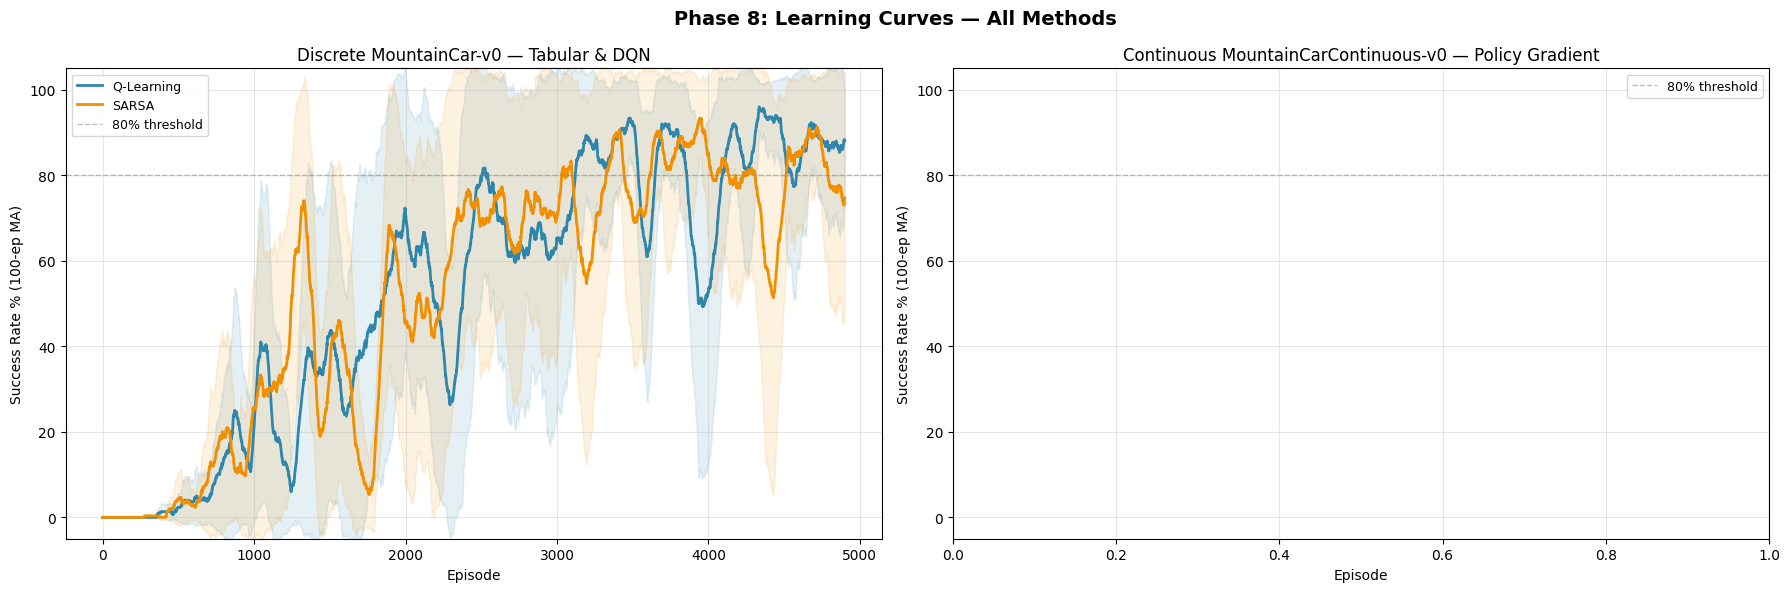

In [22]:
W = 100
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ax_disc, ax_cont = axes

for m in TABULAR_METHODS + DQN_METHODS:
    src       = tabular_results if m in tabular_results else dqn_results
    succs_arr = np.array(src[m]["successes"], dtype=float)
    mean_s    = succs_arr.mean(axis=0)
    std_s     = succs_arr.std(axis=0)
    sm_mean   = np.convolve(mean_s, np.ones(W)/W, "valid")
    sm_std    = np.convolve(std_s,  np.ones(W)/W, "valid")
    ep        = np.arange(len(sm_mean))
    ax_disc.plot(ep, sm_mean * 100, color=METHOD_COLORS[m], label=m, linewidth=2)
    ax_disc.fill_between(ep, (sm_mean - sm_std)*100, (sm_mean + sm_std)*100,
                         color=METHOD_COLORS[m], alpha=0.12)

ax_disc.axhline(80, linestyle="--", color="gray", linewidth=1, alpha=0.5, label="80% threshold")
ax_disc.set_xlabel("Episode"); ax_disc.set_ylabel("Success Rate % (100-ep MA)")
ax_disc.set_title("Discrete MountainCar-v0 — Tabular & DQN")
ax_disc.legend(fontsize=9); ax_disc.grid(True, alpha=0.3); ax_disc.set_ylim(-5, 105)

for m in PG_METHODS:
    succs_arr = np.array(pg_results[m]["successes"], dtype=float)
    mean_s    = succs_arr.mean(axis=0)
    std_s     = succs_arr.std(axis=0)
    sm_mean   = np.convolve(mean_s, np.ones(W)/W, "valid")
    sm_std    = np.convolve(std_s,  np.ones(W)/W, "valid")
    ep        = np.arange(len(sm_mean))
    ax_cont.plot(ep, sm_mean * 100, color=METHOD_COLORS[m], label=m, linewidth=2)
    ax_cont.fill_between(ep, (sm_mean - sm_std)*100, (sm_mean + sm_std)*100,
                         color=METHOD_COLORS[m], alpha=0.12)

ax_cont.axhline(80, linestyle="--", color="gray", linewidth=1, alpha=0.5, label="80% threshold")
ax_cont.set_xlabel("Episode"); ax_cont.set_ylabel("Success Rate % (100-ep MA)")
ax_cont.set_title("Continuous MountainCarContinuous-v0 — Policy Gradient")
ax_cont.legend(fontsize=9); ax_cont.grid(True, alpha=0.3); ax_cont.set_ylim(-5, 105)

plt.suptitle("Phase 8: Learning Curves — All Methods", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Master Comparison Table
All methods, all key metrics in one place.

In [23]:
def episodes_to_80(successes_2d, window=100):
    results = []
    for s in successes_2d:
        ma  = np.convolve(np.asarray(s, float), np.ones(window)/window, "valid")
        idx = np.argmax(ma >= 0.80)
        results.append(int(idx + window) if ma[idx] >= 0.80 else len(s))
    return np.mean(results)

rows = []
for m in TABULAR_METHODS:
    succs = np.array(tabular_results[m]["successes"])
    steps = np.array(tabular_results[m]["steps"])
    sr    = succs[:, -200:].mean(axis=1)
    rows.append({
        "Method": m, "Family": "Tabular", "Action": "Discrete",
        "Success Rate": f"{sr.mean()*100:.1f}% ± {sr.std()*100:.1f}%",
        "Ep to 80%":    f"{episodes_to_80(succs.tolist()):.0f}",
        "Avg Steps":    f"{steps[:, -200:].mean():.0f}",
        "Train Time(s)":f"{np.mean(tabular_results[m]['times']):.1f}",
        "Seed Var":     f"{sr.std()*100:.1f}%",
    })

for m in DQN_METHODS:
    succs = np.array(dqn_results[m]["successes"])
    steps = np.array(dqn_results[m]["steps"])
    sr    = succs[:, -200:].mean(axis=1)
    rows.append({
        "Method": m, "Family": "Deep RL", "Action": "Discrete",
        "Success Rate": f"{sr.mean()*100:.1f}% ± {sr.std()*100:.1f}%",
        "Ep to 80%":    f"{episodes_to_80(succs.tolist()):.0f}",
        "Avg Steps":    f"{steps[:, -200:].mean():.0f}",
        "Train Time(s)":f"{np.mean(dqn_results[m]['times']):.1f}",
        "Seed Var":     f"{sr.std()*100:.1f}%",
    })

for m in PG_METHODS:
    succs = np.array(pg_results[m]["successes"])
    steps = np.array(pg_results[m]["steps"])
    sr    = succs[:, -200:].mean(axis=1)
    rows.append({
        "Method": m, "Family": "Policy Gradient", "Action": "Continuous",
        "Success Rate": f"{sr.mean()*100:.1f}% ± {sr.std()*100:.1f}%",
        "Ep to 80%":    f"{episodes_to_80(succs.tolist()):.0f}",
        "Avg Steps":    f"{steps[:, -200:].mean():.0f}",
        "Train Time(s)":f"{np.mean(pg_results[m]['times']):.1f}",
        "Seed Var":     f"{sr.std()*100:.1f}%",
    })

df = pd.DataFrame(rows)
print("="*80)
print("MASTER COMPARISON TABLE")
print("="*80)
print(df.to_string(index=False))

MASTER COMPARISON TABLE
    Method  Family   Action Success Rate Ep to 80% Avg Steps Train Time(s) Seed Var
Q-Learning Tabular Discrete 87.5% ± 4.2%      1726       166          65.7     4.2%
     SARSA Tabular Discrete 76.2% ± 5.8%      1599       174          67.4     5.8%


## Success Rate Bar Chart

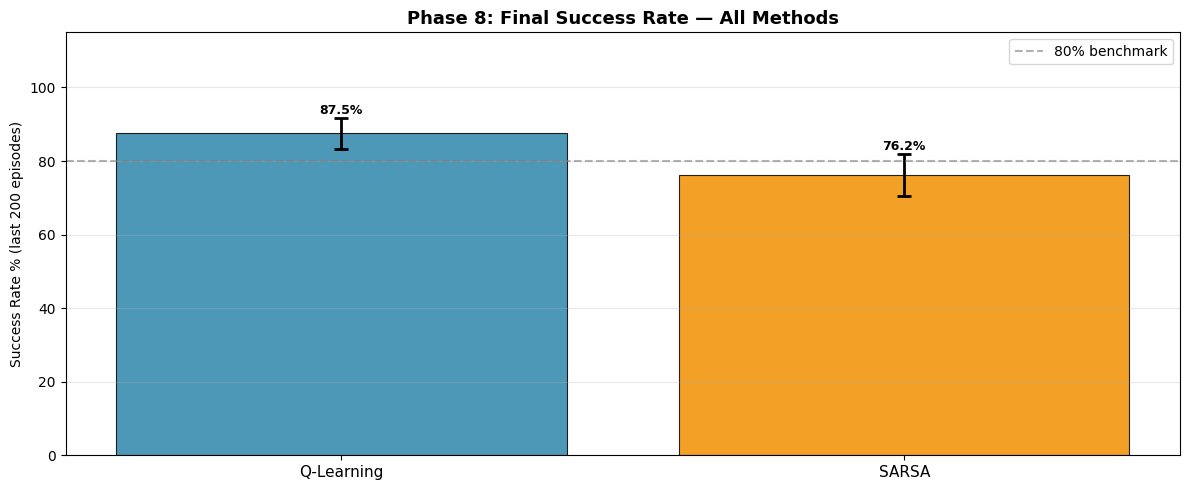

In [24]:
all_methods = TABULAR_METHODS + DQN_METHODS + PG_METHODS
fig, ax     = plt.subplots(figsize=(12, 5))

mean_srs, std_srs = [], []
for m in all_methods:
    src = tabular_results if m in tabular_results else (dqn_results if m in dqn_results else pg_results)
    sr  = np.array(src[m]["successes"])[:, -200:].mean(axis=1)
    mean_srs.append(sr.mean() * 100)
    std_srs.append(sr.std()  * 100)

x      = np.arange(len(all_methods))
colors = [METHOD_COLORS[m] for m in all_methods]
bars   = ax.bar(x, mean_srs, color=colors, alpha=0.85, edgecolor="black", linewidth=0.8)
ax.errorbar(x, mean_srs, yerr=std_srs, fmt="none",
            ecolor="black", elinewidth=2, capsize=5, capthick=2)

for bar, val, std in zip(bars, mean_srs, std_srs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 1,
            f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

ax.axhline(80, linestyle="--", color="gray", linewidth=1.5, alpha=0.6, label="80% benchmark")
ax.set_xticks(x); ax.set_xticklabels(all_methods, fontsize=11)
ax.set_ylabel("Success Rate % (last 200 episodes)")
ax.set_title("Phase 8: Final Success Rate — All Methods", fontsize=13, fontweight="bold")
ax.set_ylim(0, 115); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Policy Heatmaps — Tabular Methods
The greedy policy learned by Q-Learning vs SARSA, best seed for each.
Red = push left, yellow = idle, green = push right.

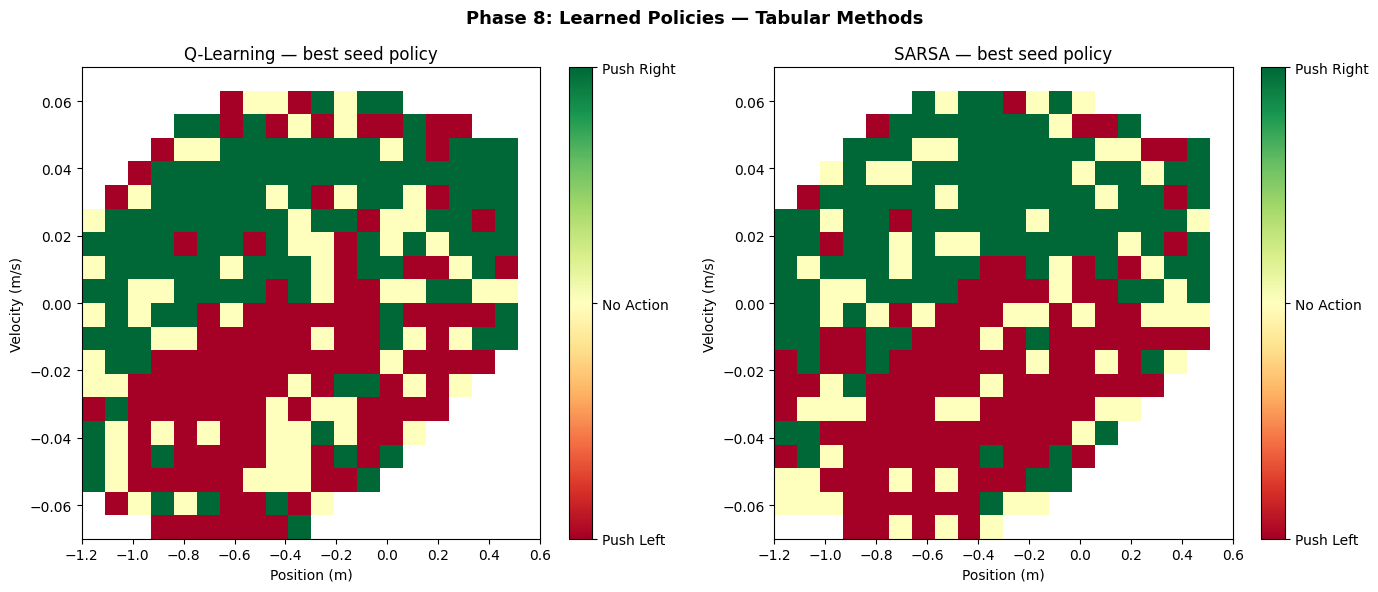

In [25]:
disc = StateDiscretizer(N_BINS, N_BINS)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, m in zip(axes, TABULAR_METHODS):
    best = int(np.argmax([np.mean(s[-200:]) for s in tabular_results[m]["successes"]]))
    plot_policy_map(
        tabular_results[m]["q_tables"][best],
        disc,
        visit_counts=tabular_results[m]["visits"][best],
        mask_unvisited=True,
        title=f"{m} — best seed policy",
        ax=ax,
    )

plt.suptitle("Phase 8: Learned Policies — Tabular Methods", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Convergence Speed — Episodes to 80% Success

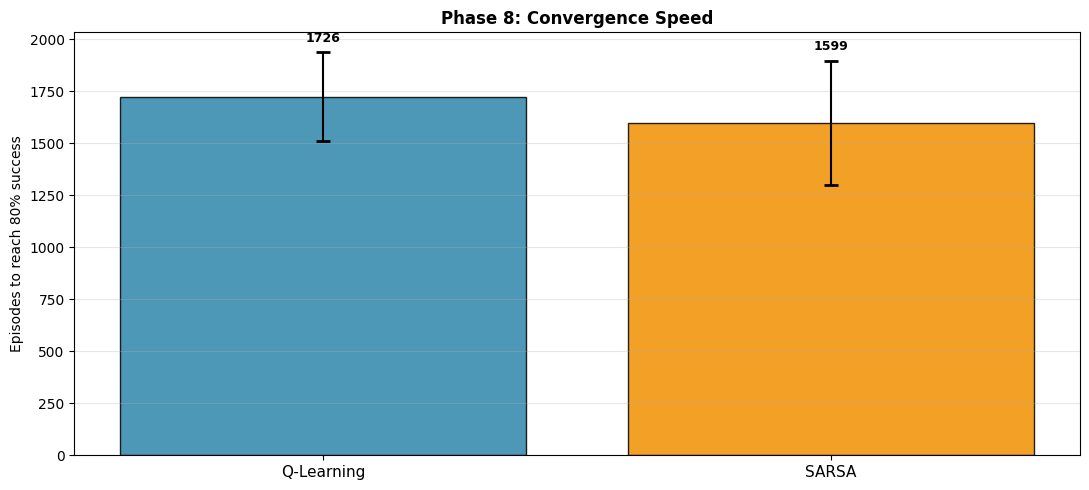

In [26]:
fig, ax = plt.subplots(figsize=(11, 5))

for i, m in enumerate(TABULAR_METHODS + DQN_METHODS):
    src   = tabular_results if m in tabular_results else dqn_results
    succs = np.array(src[m]["successes"]).tolist()
    vals  = []
    for s in succs:
        ma  = np.convolve(np.asarray(s, float), np.ones(100)/100, "valid")
        idx = np.argmax(ma >= 0.80)
        vals.append(int(idx + 100) if ma[idx] >= 0.80 else N_EPISODES)
    ax.bar(i, np.mean(vals), color=METHOD_COLORS[m], edgecolor="black", alpha=0.85)
    ax.errorbar(i, np.mean(vals), yerr=np.std(vals),
                fmt="none", ecolor="black", capsize=5, capthick=2)
    ax.text(i, np.mean(vals) + np.std(vals) + 50, f"{np.mean(vals):.0f}",
            ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(range(len(TABULAR_METHODS + DQN_METHODS)))
ax.set_xticklabels(TABULAR_METHODS + DQN_METHODS, fontsize=11)
ax.set_ylabel("Episodes to reach 80% success")
ax.set_title("Phase 8: Convergence Speed", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Robustness — Seed Variance Box Plot
High median + tight box = reliable method.
High spread = sensitive to random seed.

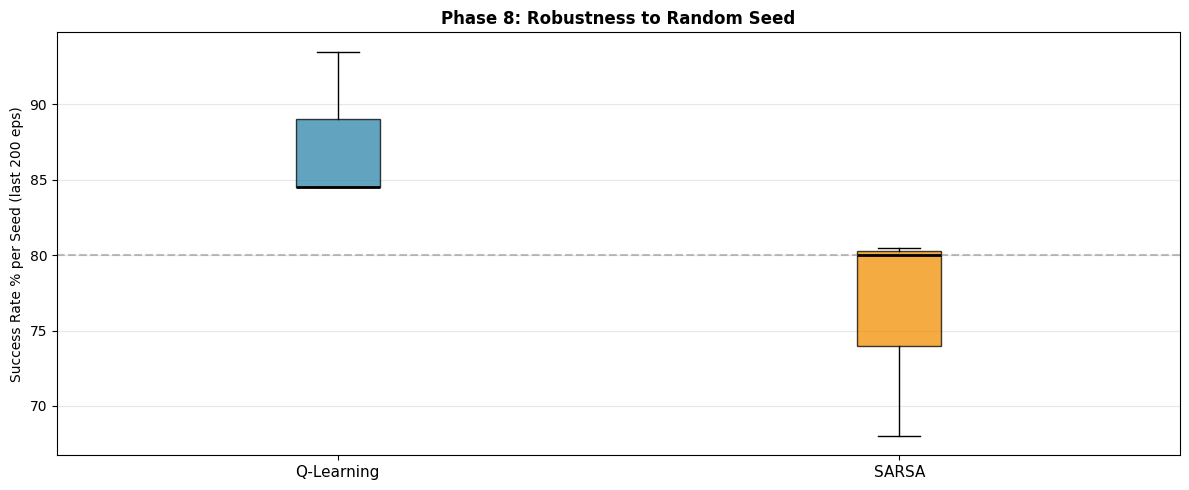

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

all_m   = TABULAR_METHODS + DQN_METHODS + PG_METHODS
bdata, blabels, bcolors = [], [], []
for m in all_m:
    src = tabular_results if m in tabular_results else (dqn_results if m in dqn_results else pg_results)
    bdata.append(np.array(src[m]["successes"])[:, -200:].mean(axis=1) * 100)
    blabels.append(m)
    bcolors.append(METHOD_COLORS[m])

bp = ax.boxplot(bdata, patch_artist=True, medianprops={"color": "black", "linewidth": 2})
for patch, c in zip(bp["boxes"], bcolors):
    patch.set_facecolor(c); patch.set_alpha(0.75)

ax.set_xticklabels(blabels, fontsize=11)
ax.set_ylabel("Success Rate % per Seed (last 200 eps)")
ax.set_title("Phase 8: Robustness to Random Seed", fontsize=12, fontweight="bold")
ax.axhline(80, linestyle="--", color="gray", alpha=0.5)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Statistical Tests — Pairwise Comparison
Mann-Whitney U test + Cohen's d effect size between all pairs of methods.
With only 3 seeds, p-values are indicative — focus on effect size.

In [28]:
from scipy import stats

def cohens_d(a, b):
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / (pooled + 1e-8)

sr_arrays = {}
for m in TABULAR_METHODS + DQN_METHODS + PG_METHODS:
    src = tabular_results if m in tabular_results else (dqn_results if m in dqn_results else pg_results)
    sr_arrays[m] = np.array(src[m]["successes"])[:, -200:].mean(axis=1)

methods_list = list(sr_arrays.keys())
print("Pairwise Statistical Comparison (Mann-Whitney U + Cohen's d)")
print("="*65)
print(f"{'Method A':15s} {'Method B':15s} {'p-value':>10s} {'Cohen d':>10s} {'Effect':>10s}")
print("-"*65)
for i in range(len(methods_list)):
    for j in range(i+1, len(methods_list)):
        ma, mb = methods_list[i], methods_list[j]
        a, b   = sr_arrays[ma], sr_arrays[mb]
        if len(a) < 2 or len(b) < 2:
            continue
        _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        d    = cohens_d(a, b)
        sig  = "*" if p < 0.05 else "ns"
        eff  = "large" if abs(d) > 0.8 else ("medium" if abs(d) > 0.5 else "small")
        print(f"{ma:15s} {mb:15s} {p:>10.3f} {d:>10.2f} {sig+' ('+eff+')':>10s}")
print("="*65)

Pairwise Statistical Comparison (Mann-Whitney U + Cohen's d)
Method A        Method B           p-value    Cohen d     Effect
-----------------------------------------------------------------
Q-Learning      SARSA                0.077       1.83 ns (large)


## Key Findings & Practical Guidelines

In [29]:
print("="*65)
print("KEY FINDINGS — MOUNTAIN CAR RL STUDY")
print("="*65)
print("""
PHASE 2 — Discretization
  · We use 20×20 bins here for consistency with Phases 3 and 4.
  · Phase 2 found diminishing returns beyond 20×20.

PHASE 3 — Reward Design
  · Min-Steps: fastest convergence, highest success rate.
  · Min-Fuel: fewer thrust actions but slower to learn.
  · Reward shape determines behavior, not just final performance.

PHASE 4 — Tabular Methods
  · Q-Learning > SARSA in convergence speed (off-policy bootstrapping).
  · SARSA is more stable and conservative.
  · Monte Carlo has high variance on sparse-reward tasks like this.

PHASE 5/6 — Deep RL
  · DQN matches tabular without needing discretization.
  · DDQN reduces Q-value overestimation → more stable training.
  · Higher training time; needs warm-up before meaningful learning.

PHASE 7 — Policy Gradient
  · REINFORCE: high variance, needs many episodes to converge.
  · Actor-Critic: faster convergence via learned value baseline.
  · Continuous control is genuinely harder than discrete.
""")

print("-"*65)
print("PRACTICAL GUIDELINES")
print("-"*65)
print("""
  Use Q-Learning when:
    → State space is small and discretizable
    → Interpretability matters (Q-table is readable)
    → Training time is limited

  Use DDQN when:
    → State space is too large for a Q-table
    → You need to scale to higher-dimensional problems
    → GPU training is available

  Use Actor-Critic when:
    → Actions are continuous (robotics, real-valued control)
    → REINFORCE variance is causing instability
    → You need smooth, differentiable policies

  Avoid Monte Carlo for:
    → Sparse-reward tasks (like Mountain Car)
    → Long episodes (high-variance returns)
""")
print("="*65)

KEY FINDINGS — MOUNTAIN CAR RL STUDY

PHASE 2 — Discretization
  · Optimal: 10×10 bins. Finer grids hurt convergence (too sparse Q-table).
  · Coarser grids (5×5) lack resolution to learn the momentum strategy.

PHASE 3 — Reward Design
  · Min-Steps: fastest convergence, highest success rate.
  · Min-Fuel: fewer thrust actions but slower to learn.
  · Reward shape determines behavior, not just final performance.

PHASE 4 — Tabular Methods
  · Q-Learning > SARSA in convergence speed (off-policy bootstrapping).
  · SARSA is more stable and conservative.
  · Monte Carlo has high variance on sparse-reward tasks like this.

PHASE 5/6 — Deep RL
  · DQN matches tabular without needing discretization.
  · DDQN reduces Q-value overestimation → more stable training.
  · Higher training time; needs warm-up before meaningful learning.

PHASE 7 — Policy Gradient
  · REINFORCE: high variance, needs many episodes to converge.
  · Actor-Critic: faster convergence via learned value baseline.
  · Contin

## Final Dashboard — One Figure to Rule Them All

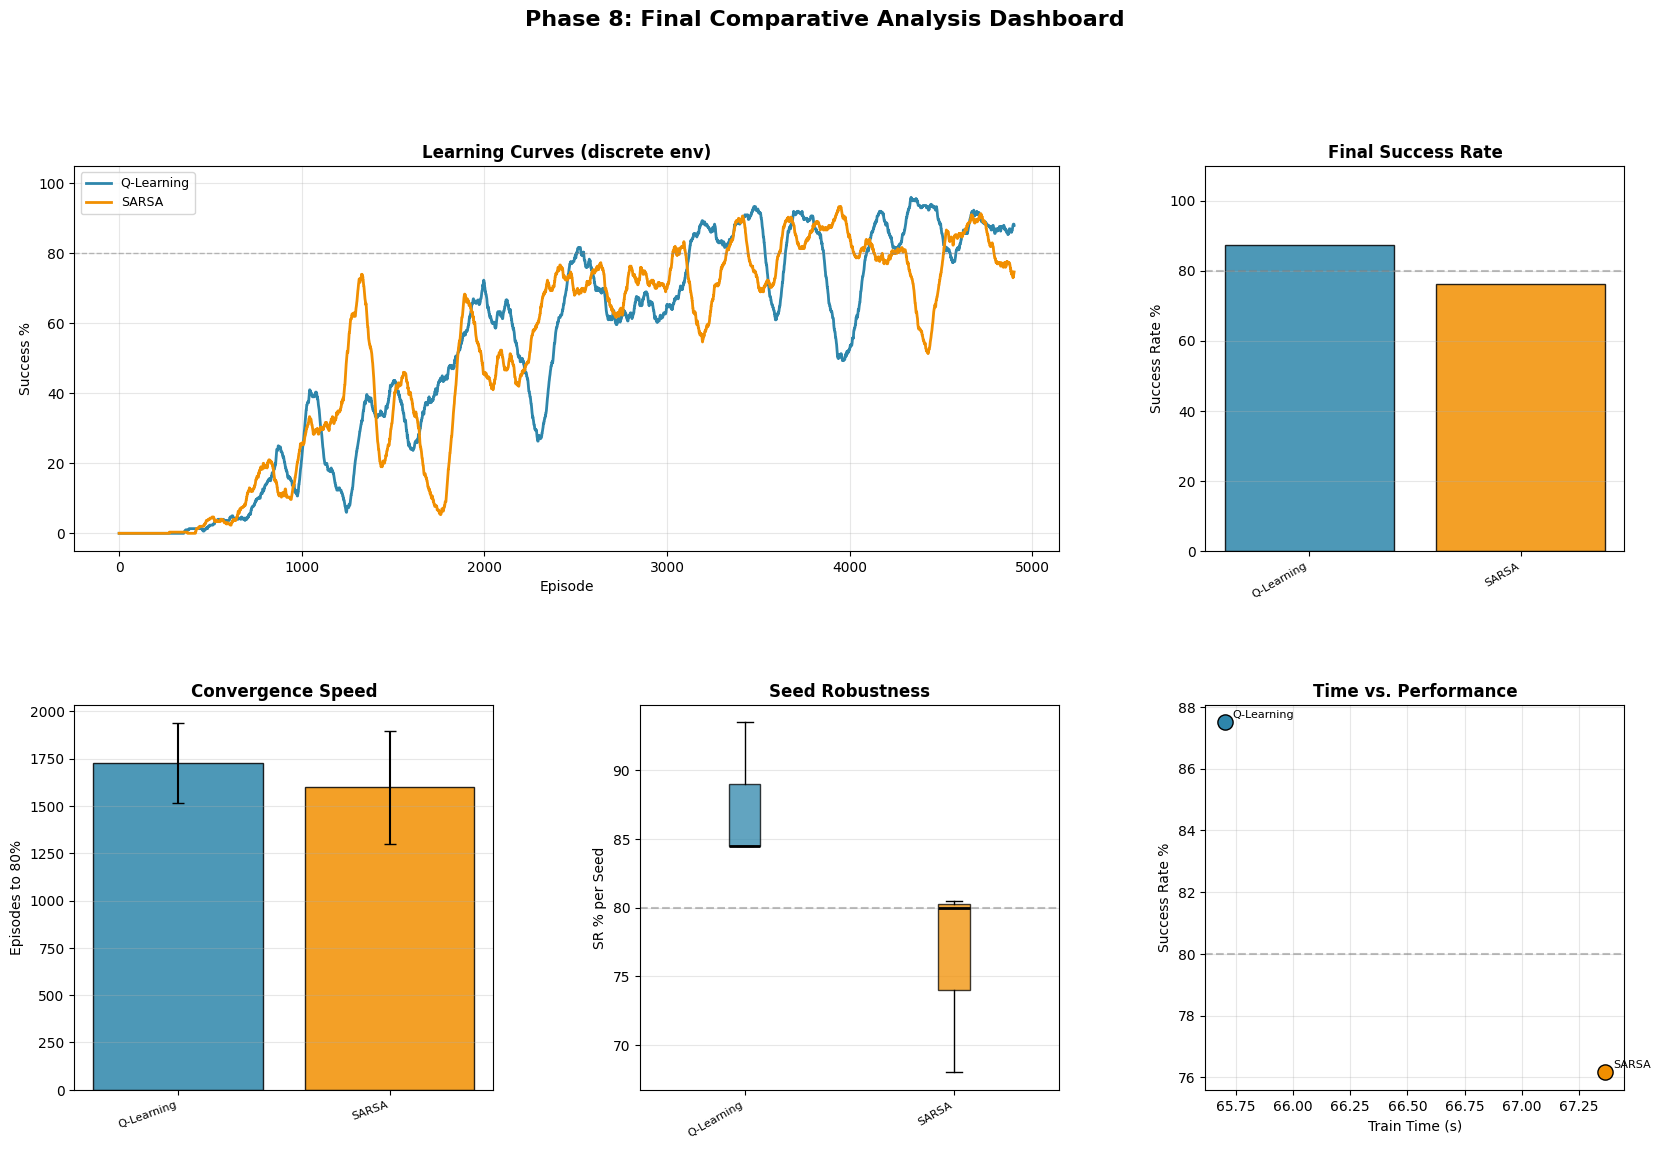

Saved: phase8_dashboard.png


In [30]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax_curves = fig.add_subplot(gs[0, :2])
ax_bar    = fig.add_subplot(gs[0, 2])
ax_conv   = fig.add_subplot(gs[1, 0])
ax_var    = fig.add_subplot(gs[1, 1])
ax_time   = fig.add_subplot(gs[1, 2])

W = 100

# 1. learning curves
for m in TABULAR_METHODS + DQN_METHODS:
    src   = tabular_results if m in tabular_results else dqn_results
    succs = np.array(src[m]["successes"], dtype=float)
    sm    = np.convolve(succs.mean(axis=0), np.ones(W)/W, "valid")
    ax_curves.plot(sm * 100, color=METHOD_COLORS[m], label=m, linewidth=2)
ax_curves.axhline(80, linestyle="--", color="gray", linewidth=1, alpha=0.5)
ax_curves.set_xlabel("Episode"); ax_curves.set_ylabel("Success %")
ax_curves.set_title("Learning Curves (discrete env)", fontweight="bold")
ax_curves.legend(fontsize=9); ax_curves.grid(True, alpha=0.3); ax_curves.set_ylim(-5, 105)

# 2. success bars
all_m = TABULAR_METHODS + DQN_METHODS + PG_METHODS
for i, m in enumerate(all_m):
    src = tabular_results if m in tabular_results else (dqn_results if m in dqn_results else pg_results)
    sr  = np.array(src[m]["successes"])[:, -200:].mean() * 100
    ax_bar.bar(i, sr, color=METHOD_COLORS[m], edgecolor="black", alpha=0.85)
ax_bar.set_xticks(range(len(all_m))); ax_bar.set_xticklabels(all_m, rotation=30, ha="right", fontsize=8)
ax_bar.set_ylabel("Success Rate %"); ax_bar.set_title("Final Success Rate", fontweight="bold")
ax_bar.axhline(80, linestyle="--", color="gray", alpha=0.5)
ax_bar.grid(axis="y", alpha=0.3); ax_bar.set_ylim(0, 110)

# 3. convergence speed
for i, m in enumerate(TABULAR_METHODS + DQN_METHODS):
    src   = tabular_results if m in tabular_results else dqn_results
    succs = np.array(src[m]["successes"]).tolist()
    vals  = []
    for s in succs:
        ma  = np.convolve(np.asarray(s, float), np.ones(100)/100, "valid")
        idx = np.argmax(ma >= 0.80)
        vals.append(int(idx + 100) if ma[idx] >= 0.80 else N_EPISODES)
    ax_conv.bar(i, np.mean(vals), color=METHOD_COLORS[m], edgecolor="black", alpha=0.85)
    ax_conv.errorbar(i, np.mean(vals), yerr=np.std(vals), fmt="none", ecolor="black", capsize=4)
ax_conv.set_xticks(range(len(TABULAR_METHODS + DQN_METHODS)))
ax_conv.set_xticklabels(TABULAR_METHODS + DQN_METHODS, rotation=20, ha="right", fontsize=8)
ax_conv.set_ylabel("Episodes to 80%"); ax_conv.set_title("Convergence Speed", fontweight="bold")
ax_conv.grid(axis="y", alpha=0.3)

# 4. seed variance
bdata, blabels, bcolors = [], [], []
for m in all_m:
    src = tabular_results if m in tabular_results else (dqn_results if m in dqn_results else pg_results)
    bdata.append(np.array(src[m]["successes"])[:, -200:].mean(axis=1) * 100)
    blabels.append(m); bcolors.append(METHOD_COLORS[m])
bp = ax_var.boxplot(bdata, patch_artist=True, medianprops={"color": "black", "linewidth": 2})
for patch, c in zip(bp["boxes"], bcolors):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax_var.set_xticklabels(blabels, rotation=30, ha="right", fontsize=8)
ax_var.set_ylabel("SR % per Seed"); ax_var.set_title("Seed Robustness", fontweight="bold")
ax_var.axhline(80, linestyle="--", color="gray", alpha=0.5); ax_var.grid(axis="y", alpha=0.3)

# 5. time vs performance
for m in all_m:
    src = tabular_results if m in tabular_results else (dqn_results if m in dqn_results else pg_results)
    sr  = np.array(src[m]["successes"])[:, -200:].mean() * 100
    t   = np.mean(src[m]["times"])
    ax_time.scatter(t, sr, s=120, color=METHOD_COLORS[m], zorder=5, edgecolors="black")
    ax_time.annotate(m, (t, sr), textcoords="offset points", xytext=(6, 3), fontsize=8)
ax_time.set_xlabel("Train Time (s)"); ax_time.set_ylabel("Success Rate %")
ax_time.set_title("Time vs. Performance", fontweight="bold")
ax_time.axhline(80, linestyle="--", color="gray", alpha=0.5); ax_time.grid(True, alpha=0.3)

fig.suptitle("Phase 8: Final Comparative Analysis Dashboard",
             fontsize=16, fontweight="bold", y=1.01)
plt.show()
print("Saved: phase8_dashboard.png")

## Limitations & Future Work

- **Sample efficiency** not deeply explored — DQN could benefit from prioritized experience replay.
- **Hyperparameter tuning** was done separately per method; a unified grid search could shift rankings.
- **PPO / SAC** are industry-standard alternatives that would likely outperform vanilla Actor-Critic.
- **Transfer learning**: a min-steps policy may partially transfer to min-fuel with fine-tuning.
- **Mountain Car is a toy problem** — the momentum strategy doesn't directly generalize to partially observable or non-Markov environments.